Saving set_1.class to set_1 (3).class
Saving set_2.class to set_2 (3).class
Uploaded: ['set_1 (3).class', 'set_2 (3).class']
set_1 (3).class: n=286470 | positives=184 | negatives=286286
set_2 (3).class: n=287161 | positives=184 | negatives=286977
[set_1 (3).class] t=0.001  TP=184 FP=2 FN=0 TN=286284  MCC=0.994606
[set_2 (3).class] t=0.001  TP=182 FP=5 FN=2 TN=286972  MCC=0.981152
[set_1 (3).class] t=0.002  TP=184 FP=3 FN=0 TN=286283  MCC=0.991941
[set_2 (3).class] t=0.002  TP=182 FP=7 FN=2 TN=286970  MCC=0.975943
[set_1 (3).class] t=0.01  TP=184 FP=11 FN=0 TN=286275  MCC=0.971367
[set_2 (3).class] t=0.01  TP=184 FP=17 FN=0 TN=286960  MCC=0.956749
MCC fold1: [0.9186601425230922, 0.9713668143045582, 0.9946056509619731, 0.9972918933117055, 1.0, 0.9972771647725148, 0.9945468941909782, 0.9945468941909782, 0.9945468941909782]
MCC fold2: [0.9082950926813583, 0.9567490044787601, 0.9811519996476797, 0.9782469311659728, 0.9863260175177575, 0.9890638171345189, 0.9890638171345189, 0.98906381713451

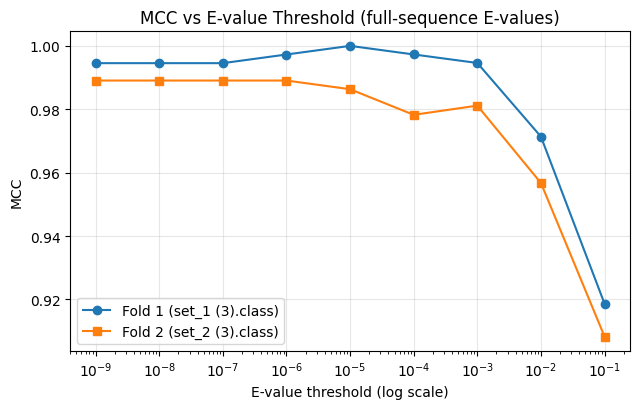

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import io
import math
import numpy as np
import matplotlib.pyplot as plt

# Upload files manually
try:
    from google.colab import files  # Colab
    uploaded = files.upload()       # upload set_1.class and set_2.class
    print("Uploaded:", list(uploaded.keys()))
except Exception as e:
    # Not Colab: you must place files in the current working directory
    import os
    print("Not running in Colab (or upload UI not available).")
    print("Current directory:", os.getcwd())
    print("Files here:", os.listdir())
    uploaded = None


def parse_class_content(text, evalue_source="full"):
    """
    Expected per line (whitespace separated):
    ID  label  full_seq_Evalue  best_domain_Evalue
    label: 1 (positive), 0 (negative)
    """
    col = 2 if evalue_source == "full" else 3
    data = []
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) < 4:
            continue
        label = int(parts[1])
        evalue = float(parts[col])
        data.append((label, evalue))
    return data

def load_class_file(filename, evalue_source="full"):
    if uploaded is not None:
        if filename not in uploaded:
            raise FileNotFoundError(f"{filename} not found in uploaded files: {list(uploaded.keys())}")
        text = uploaded[filename].decode("utf-8", errors="replace")
        return parse_class_content(text, evalue_source=evalue_source)
    else:
        with open(filename, "r", encoding="utf-8", errors="replace") as f:
            return parse_class_content(f.read(), evalue_source=evalue_source)

def confusion_at_threshold(data, t):
    # predict positive if evalue <= t
    TP = FP = TN = FN = 0
    for y, e in data:
        pred = 1 if e <= t else 0
        if pred == 1 and y == 1: TP += 1
        elif pred == 1 and y == 0: FP += 1
        elif pred == 0 and y == 0: TN += 1
        else: FN += 1
    return TP, FP, TN, FN

def mcc(TP, FP, TN, FN):
    num = TP*TN - FP*FN
    den = math.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return num/den if den != 0 else 0.0

# Settings you can change quickly
EVAL_SOURCE = "full"   # "full" or "domain"
THRESHOLDS  = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
FILE1 = next(k for k in uploaded if k.startswith("set_1"))
FILE2 = next(k for k in uploaded if k.startswith("set_2"))


# Load data
FILE1 = next(k for k in uploaded if k.startswith("set_1"))
FILE2 = next(k for k in uploaded if k.startswith("set_2"))


data1 = load_class_file(FILE1, evalue_source=EVAL_SOURCE)
data2 = load_class_file(FILE2, evalue_source=EVAL_SOURCE)

print(f"{FILE1}: n={len(data1)} | positives={sum(y==1 for y,_ in data1)} | negatives={sum(y==0 for y,_ in data1)}")
print(f"{FILE2}: n={len(data2)} | positives={sum(y==1 for y,_ in data2)} | negatives={sum(y==0 for y,_ in data2)}")


# Sanity check at a known-good threshold
for t in [1e-3, 2e-3, 1e-2]:
    TP, FP, TN, FN = confusion_at_threshold(data1, t)
    print(f"[{FILE1}] t={t:g}  TP={TP} FP={FP} FN={FN} TN={TN}  MCC={mcc(TP,FP,TN,FN):.6f}")
    TP, FP, TN, FN = confusion_at_threshold(data2, t)
    print(f"[{FILE2}] t={t:g}  TP={TP} FP={FP} FN={FN} TN={TN}  MCC={mcc(TP,FP,TN,FN):.6f}")

# MCC curve
mcc1, mcc2 = [], []
for t in THRESHOLDS:
    TP, FP, TN, FN = confusion_at_threshold(data1, t)
    mcc1.append(mcc(TP, FP, TN, FN))
    TP, FP, TN, FN = confusion_at_threshold(data2, t)
    mcc2.append(mcc(TP, FP, TN, FN))

print("MCC fold1:", mcc1)
print("MCC fold2:", mcc2)

# Plot
fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(THRESHOLDS, mcc1, marker="o", label=f"Fold 1 ({FILE1})")
ax.plot(THRESHOLDS, mcc2, marker="s", label=f"Fold 2 ({FILE2})")

ax.set_xscale("log")
ax.set_xlabel("E-value threshold (log scale)")
ax.set_ylabel("MCC")
ax.set_title(f"MCC vs E-value Threshold ({EVAL_SOURCE}-sequence E-values)")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig("Figure_2_MCC_vs_Evalue_threshold.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("Figure_2_MCC_vs_Evalue_threshold.png")
